In [1]:
# Problem 1 Comprehensive Notebook

# --- 1. Introduction ---
"""
This notebook addresses Problem 1:
- Identify the most popular locations and when they are popular using credit card data.
- Detect anomalies in visit patterns.
- Recommend corrections based on detected anomalies.
"""

# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
# --- 2. Data Loading and Cleaning ---

# Load credit card data
cc_df = pd.read_csv('../cleaned_data/cc_data_cleaned.csv')

# Convert timestamp to datetime
cc_df['timestamp'] = pd.to_datetime(cc_df['timestamp'])

print(cc_df.head())

            timestamp             location  price  last4ccnum        date  \
0 2014-01-06 07:28:00  Brew've Been Served  11.34        4795  2014-01-06   
1 2014-01-06 07:34:00     Hallowed Grounds  52.22        7108  2014-01-06   
2 2014-01-06 07:35:00  Brew've Been Served   8.33        6816  2014-01-06   
3 2014-01-06 07:36:00     Hallowed Grounds  16.72        9617  2014-01-06   
4 2014-01-06 07:37:00  Brew've Been Served   4.24        7384  2014-01-06   

   hour  minute dayofweek  is_weekend  
0     7      28    Monday       False  
1     7      34    Monday       False  
2     7      35    Monday       False  
3     7      36    Monday       False  
4     7      37    Monday       False  


/var/folders/gz/b07vrg811_b1gw2cvpntg_kr0000gn/T/ipykernel_21869/4198866200.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='visit_count', y='location', data=popular_locations, palette='mako')
/Users/ianunebasami/micromamba/envs/MC2_streamlit/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


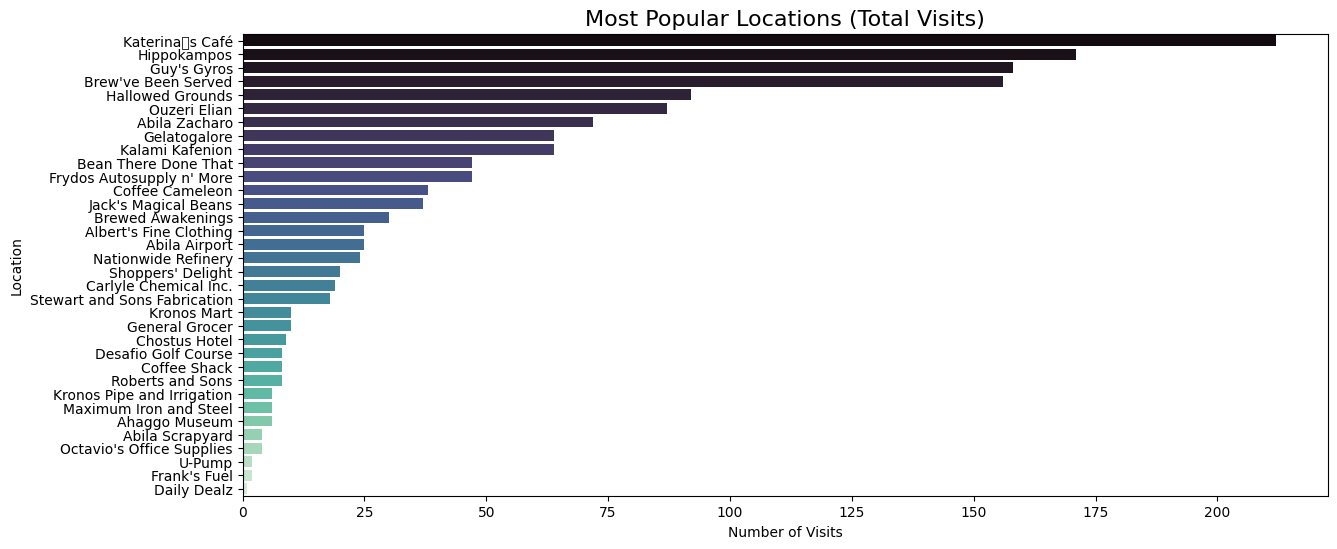

In [3]:
# --- 3. Exploratory Analysis: Most Popular Locations ---

# Group by location
popular_locations = cc_df['location'].value_counts().reset_index()
popular_locations.columns = ['location', 'visit_count']

# Plot the most popular locations
plt.figure(figsize=(14,6))
sns.barplot(x='visit_count', y='location', data=popular_locations, palette='mako')
plt.title('Most Popular Locations (Total Visits)', fontsize=16)
plt.xlabel('Number of Visits')
plt.ylabel('Location')
plt.show()
popular_locations.to_csv('plots/popular_locations.csv', index=False)

/Users/ianunebasami/micromamba/envs/MC2_streamlit/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/ianunebasami/micromamba/envs/MC2_streamlit/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


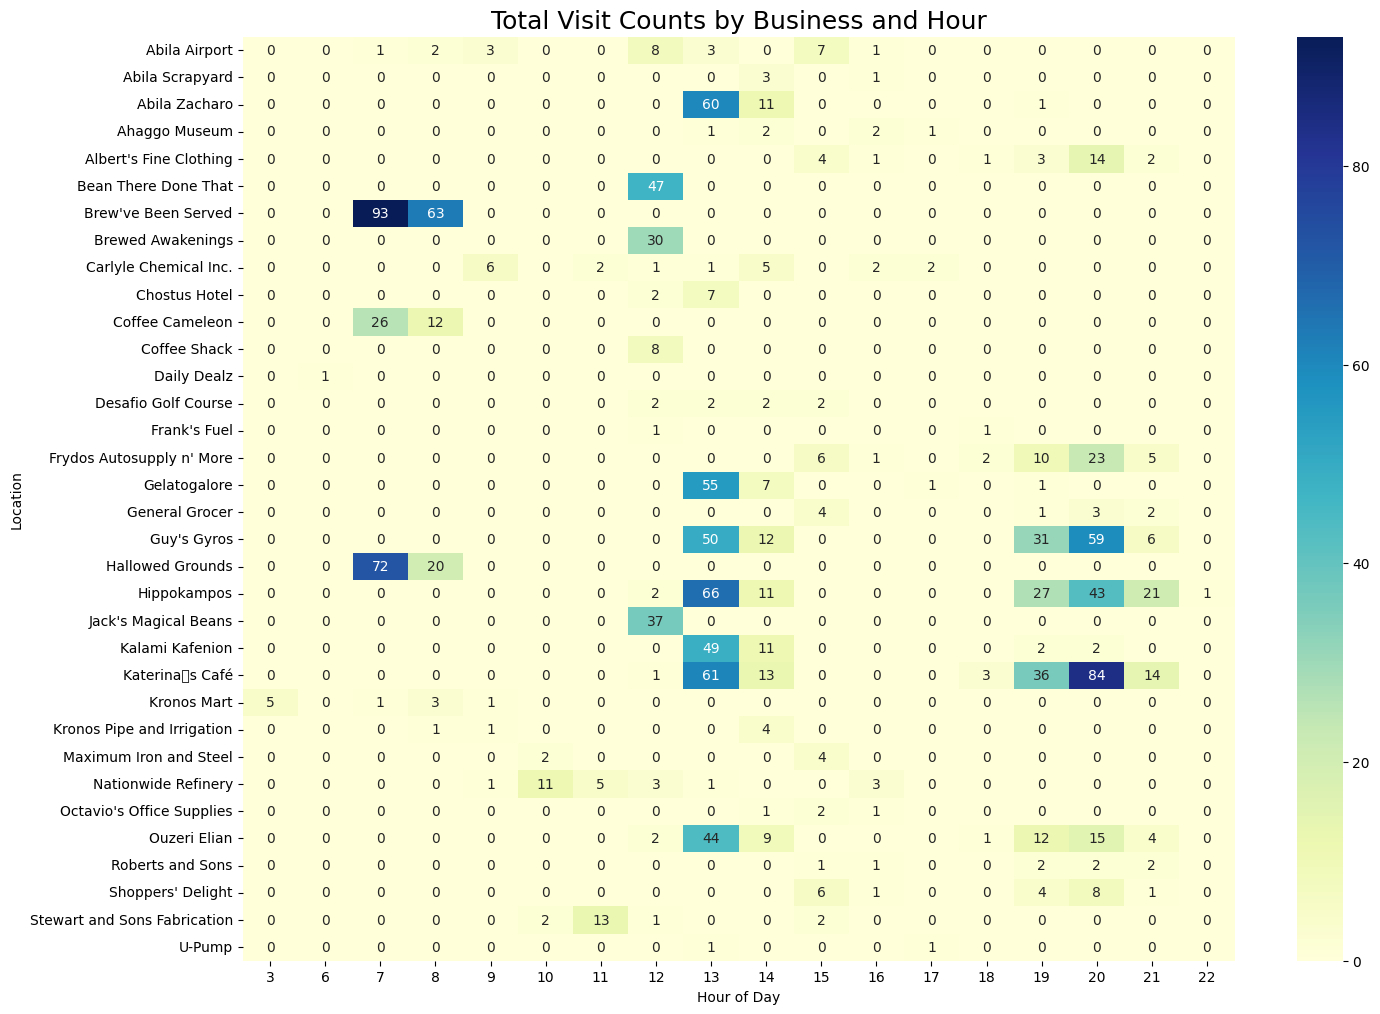

In [6]:
# --- 4. Temporal Patterns: Visits by Hour ---

# Group by location and hour
visits_by_hour = cc_df.groupby(['location', 'hour']).size().reset_index(name='visit_count')

# Pivot table for heatmap
pivot_table = visits_by_hour.pivot(index='location', columns='hour', values='visit_count').fillna(0)

# Plot heatmap
plt.figure(figsize=(16,12))
sns.heatmap(pivot_table, cmap='YlGnBu', annot=True, fmt='.0f')
plt.title('Total Visit Counts by Business and Hour', fontsize=18)
plt.xlabel('Hour of Day')
plt.ylabel('Location')
plt.show()
pivot_table.to_csv('plots/pivot_table.csv', index=True)

In [24]:
# --- 5. Anomaly Detection (Final Version: Median + IQR + Low-Sample Filtering) ---

# Step 1: Calculate daily visits per location-hour
actual_visits = cc_df.groupby(['date', 'location', 'hour']).size().reset_index(name='actual_visit_count')

# Step 2: Filter out low-sample location-hour groups
# Count how many daily records each location-hour has
group_counts = actual_visits.groupby(['location', 'hour']).size().reset_index(name='count')

# Only keep location-hours with at least 5 days of activity
sufficient_groups = group_counts[group_counts['count'] >= 5]

# Merge to filter actual_visits
actual_visits_filtered = actual_visits.merge(sufficient_groups[['location', 'hour']], on=['location', 'hour'])

# Step 3: Calculate median daily visits per location-hour
median_summary = actual_visits_filtered.groupby(['location', 'hour'])['actual_visit_count'].median().reset_index(name='median_visit_count')


# --- IQR-based Anomaly Detection ---
# For each location-hour group:
# - Calculate Q1 (25th percentile) and Q3 (75th percentile) of daily visit counts
# - Compute IQR = Q3 - Q1
# - Define lower bound = Q1 - 1.5*IQR and upper bound = Q3 + 1.5*IQR
# - Any daily visit count outside this range is flagged as an anomaly
# This method is robust against outliers and adapts to different industries' traffic patterns.
iqr_summary = actual_visits_filtered.groupby(['location', 'hour'])['actual_visit_count'].agg(
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
).reset_index()

# Calculate IQR, lower bound, and upper bound
iqr_summary['IQR'] = iqr_summary['Q3'] - iqr_summary['Q1']
iqr_summary['lower_bound'] = iqr_summary['Q1'] - 1.5 * iqr_summary['IQR']
iqr_summary['upper_bound'] = iqr_summary['Q3'] + 1.5 * iqr_summary['IQR']

# Step 5: Merge everything together
merged = actual_visits_filtered.merge(median_summary, on=['location', 'hour'])
merged = merged.merge(iqr_summary[['location', 'hour', 'lower_bound', 'upper_bound']], on=['location', 'hour'])

# Step 6: Flag anomalies based on IQR bounds
merged['anomaly'] = np.where(
    (merged['actual_visit_count'] < merged['lower_bound']) | (merged['actual_visit_count'] > merged['upper_bound']),
    'Yes', 'No'
)

# Step 7: View detected anomalies
anomalies = merged[merged['anomaly'] == 'Yes']
print(f"Detected {len(anomalies)} anomalies after filtering low-sample groups.")

# (Optional) View top anomalies
anomalies.head(10)

Detected 29 anomalies after filtering low-sample groups.


,date,location,hour,actual_visit_count,median_visit_count,lower_bound,upper_bound,anomaly
1,2014-01-06,Abila Airport,15,2,1.0,1.000,1.000,Yes
44,2014-01-07,Brewed Awakenings,12,4,3.0,3.000,3.000,Yes
137,2014-01-09,Jack's Magical Beans,12,5,4.0,4.000,4.000,Yes
144,2014-01-09,Katerinas Café,21,1,2.0,1.375,2.375,Yes
152,2014-01-10,Abila Zacharo,14,3,1.0,0.625,1.625,Yes
164,2014-01-10,Guy's Gyros,13,8,4.0,2.500,6.500,Yes
181,2014-01-10,Nationwide Refinery,10,2,1.0,1.000,1.000,Yes
198,2014-01-11,Katerinas Café,19,7,2.0,0.625,3.625,Yes
207,2014-01-12,Guy's Gyros,13,1,4.0,2.500,6.500,Yes
215,2014-01-12,Katerinas Café,19,4,2.0,0.625,3.625,Yes


/Users/ianunebasami/micromamba/envs/MC2/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


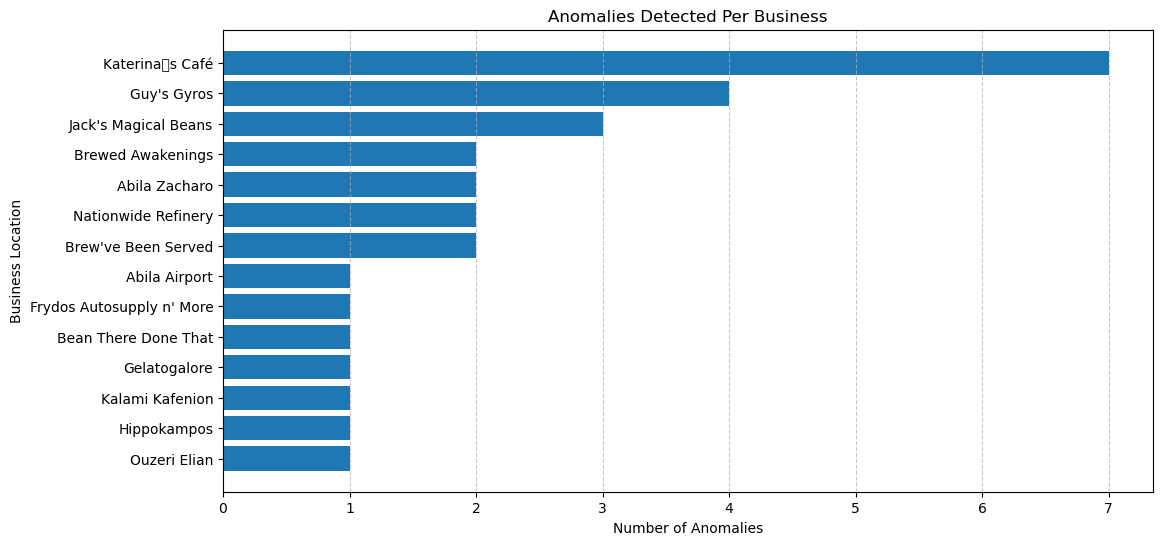

In [25]:
# --- 7. Visualization: Anomalies per Business ---

import matplotlib.pyplot as plt

# Count anomalies per location
anomaly_counts = anomalies['location'].value_counts().reset_index()
anomaly_counts.columns = ['location', 'num_anomalies']

# Plot
plt.figure(figsize=(12,6))
plt.barh(anomaly_counts['location'], anomaly_counts['num_anomalies'])
plt.xlabel('Number of Anomalies')
plt.ylabel('Business Location')
plt.title('Anomalies Detected Per Business')
plt.gca().invert_yaxis()  # So the business with most anomalies is at top
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

anomaly_counts.to_csv('plots/anomaly_counts.csv', index=False)

**Conclusion**
<br>
In this analysis, we aimed to identify patterns of typical customer traffic across various business locations and flag anomalous behavior based on deviations from those patterns.
To robustly handle the sparsity and variability inherent in the dataset, we filtered out location-hour groups with fewer than 5 active days and used a median and IQR-based anomaly detection method rather than simple averages.

This approach resulted in the detection of 29 anomalies across the 14-day period.
The anomalies were concentrated primarily among cafés, restaurants, and food service businesses such as Katerina’s Café, Guy’s Gyros, and Jack’s Magical Beans.
Most irregularities occurred during peak operating hours (lunchtime and evening), aligning with real-world expectations about when customer traffic is most sensitive to disruptions.

Overall, the anomaly detection results were credible and pointed toward specific businesses and times that warrant further investigation.
The improved method of using medians and interquartile ranges ensured that the anomalies identified reflect meaningful deviations rather than random fluctuations, especially in a sparsely populated dataset.

Due to the lack of precise GPS coordinates for individual businesses in the provided datasets (Abila shapefiles, Kronos Island shapefiles, and MC2 Tourist Map), and in order to avoid introducing artificial or fabricated geospatial data, we chose not to construct a dynamic location-based heatmap. Instead, we focused our analysis on temporal and behavioral patterns derived directly from the transaction records, ensuring that our results are grounded solely in the provided, verifiable data.